# **DL Lab 7**
## **Name: Soumyadeep Ganguly**
## **Reg No: 24MDT0082**

In [1]:
import numpy as np
import keras
from keras.datasets import mnist, cifar10
from keras.models import Sequential
from keras.layers import Dense, Conv2D, MaxPool2D, Flatten
from keras.optimizers import SGD, Adam, RMSprop
from keras.utils import to_categorical
import keras_tuner as kt
import matplotlib.pyplot as plt
from keras.callbacks import EarlyStopping
from sklearn.model_selection import train_test_split
import tensorflow as tf

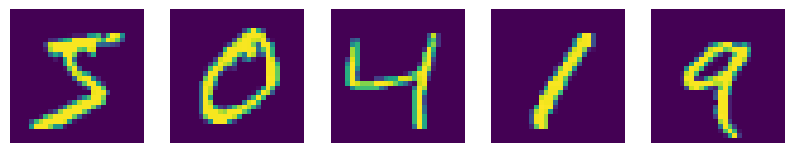

In [2]:
(X_train, y_train), (X_test, y_test) = mnist.load_data()
fig, axs = plt.subplots(1, 5, figsize=(10, 2))
for i in range(5):
    axs[i].imshow(X_train[i])
    axs[i].axis('off')    
plt.show()

In [3]:
X_train = X_train.reshape(60000, 784)
X_test = X_test.reshape(10000, 784)
X_train = X_train.astype('float32')
X_test = X_test.astype('float32')
X_train /= 255
X_test /= 255
y_train_cat = keras.utils.to_categorical(y_train, num_classes=10)
y_test_cat = keras.utils.to_categorical(y_test, num_classes=10)

# **Question 1**

In [4]:
model1 = Sequential()
model1.add(Dense(512, activation="relu", input_shape=(784,)))
model1.add(Dense(256, activation="sigmoid"))
model1.add(Dense(128, activation="sigmoid"))
model1.add(Dense(10, activation="softmax"))
model1.summary()

e:\VIT Study Materials\SEM 3\Deep Learning\LAB\.venv\Lib\site-packages\keras\src\layers\core\dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 512)            │       401,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 567,434 (2.16 MB)

 Trainable params: 567,434 (2.16 MB)

 Non-trainable params: 0 (0.00 B)

In [7]:
estop = EarlyStopping(monitor = 'val_loss', min_delta = 1e-4, mode= 'min', patience=4, verbose = 1, restore_best_weights=True)

In [ ]:
model1.compile(loss='CategoricalCrossentropy', optimizer=SGD(learning_rate=0.01), metrics=['accuracy'])
hist = model1.fit(X_train, y_train_cat, batch_size=56, epochs=50, verbose=1, validation_data=(X_test, y_test_cat), callbacks=[estop])

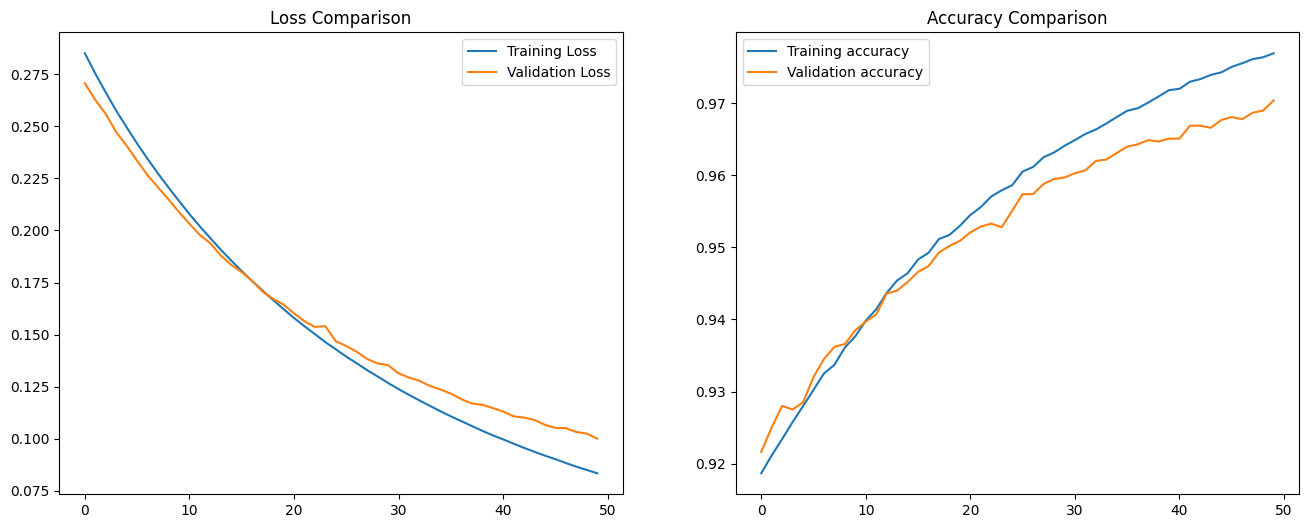

In [9]:
fig, axs = plt.subplots(1, 2, figsize=(16, 6))
axs[0].plot(hist.history['loss'], label='Training Loss')
axs[0].plot(hist.history['val_loss'], label='Validation Loss')
axs[0].set_title('Loss Comparison')
axs[1].plot(hist.history['accuracy'], label='Training accuracy')
axs[1].plot(hist.history['val_accuracy'], label='Validation accuracy')
axs[1].set_title('Accuracy Comparison')
axs[0].legend()
axs[1].legend()
plt.show()

# **Question 2**

In [10]:
(X_train, y_train), (X_test, y_test) = mnist.load_data()
X_train = X_train.astype('float32')
X_test = X_test.astype('float32')
X_train = X_train/255 
X_test = X_test/255
X_train = X_train.reshape(-1, 28,28,1)
X_test = X_test.reshape(-1, 28,28,1)
y_train_cat = keras.utils.to_categorical(y_train, num_classes=10)
y_test_cat = keras.utils.to_categorical(y_test, num_classes=10)

In [11]:
model2 = Sequential()
model2.add(Conv2D(26, 5, strides=(1, 1), activation="relu", padding='valid', input_shape=(28, 28, 1)))
model2.add(MaxPool2D(pool_size=(2,2), strides=(2,2), padding="valid"))
model2.add(Conv2D(20, 5, strides=(1, 1), activation="relu", padding='valid'))
model2.add(MaxPool2D(pool_size=(2,2), strides=(1,1), padding="valid"))
model2.add(Conv2D(10, 5, strides=(1, 1), activation="relu", padding='valid'))
model2.add(MaxPool2D(pool_size=(2,2), strides=(1,1), padding="valid"))
model2.add(Flatten())
model2.add(Dense(100, activation='relu'))
model2.add(Dense(10, activation='softmax'))
model2.summary()


e:\VIT Study Materials\SEM 3\Deep Learning\LAB\.venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 24, 24, 26)     │           676 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 12, 12, 26)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 8, 8, 20)       │        13,020 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 20)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 3, 3, 10)       │         5,010 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 2, 2, 10)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 40)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 100)            │         4,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,816 (93.03 KB)

 Trainable params: 23,816 (93.03 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model2.compile(loss='sparse_categorical_crossentropy', optimizer=SGD(learning_rate=0.01), metrics=['accuracy'])
hist2 = model2.fit(X_train, y_train, batch_size=28, epochs=20, verbose=1, validation_data=(X_test, y_test), callbacks=[estop])

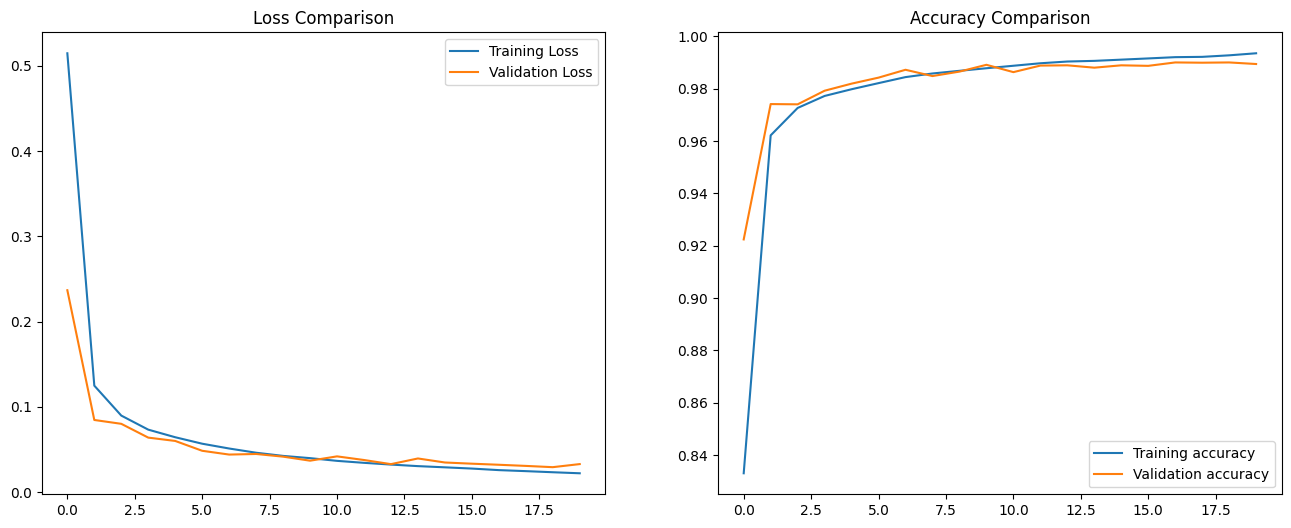

In [13]:
fig, axs = plt.subplots(1, 2, figsize=(16, 6))
axs[0].plot(hist2.history['loss'], label='Training Loss')
axs[0].plot(hist2.history['val_loss'], label='Validation Loss')
axs[0].set_title('Loss Comparison')
axs[1].plot(hist2.history['accuracy'], label='Training accuracy')
axs[1].plot(hist2.history['val_accuracy'], label='Validation accuracy')
axs[1].set_title('Accuracy Comparison')
axs[0].legend()
axs[1].legend()
plt.show()

# **Question 3**

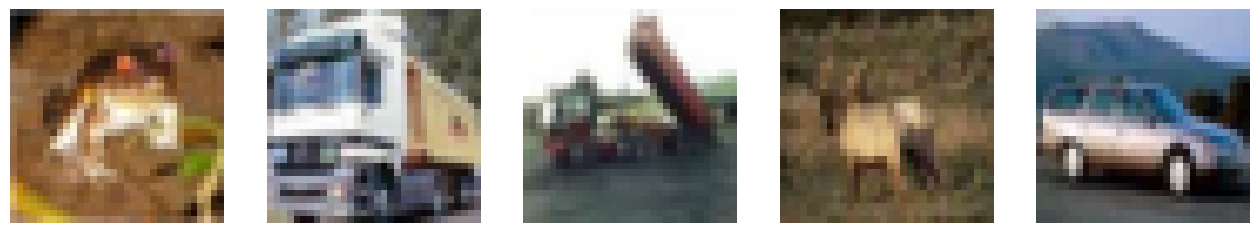

In [14]:
(X_train, y_train), (X_test, y_test) = cifar10.load_data()
fig, axs = plt.subplots(1, 5, figsize=(16, 4))
for i in range(5):
    axs[i].imshow(X_train[i])
    axs[i].axis('off')    


plt.show()


In [15]:
X_train = X_train.astype('float32')
X_test = X_test.astype('float32')
X_train = X_train/255
X_test = X_test/255

In [16]:
model3 = Sequential()
model3.add(Conv2D(30, 5, strides=[1,1], activation='relu', padding='valid', input_shape=(32,32, 3)))
model3.add(MaxPool2D(pool_size=(2,2), strides=(2,2), padding='valid'))
model3.add(Conv2D(20, 5, strides=(1, 1), activation="relu", padding='valid'))
model3.add(MaxPool2D(pool_size=(2,2), strides=(1,1), padding="valid"))
model3.add(Conv2D(10, 3, strides=(1, 1), activation="relu", padding='valid'))
model3.add(MaxPool2D(pool_size=(2,2), strides=(1,1), padding="valid"))
model3.add(Flatten())
model3.add(Dense(100, activation='relu'))
model3.add(Dense(100, activation='softmax'))
model3.summary()

e:\VIT Study Materials\SEM 3\Deep Learning\LAB\.venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 28, 28, 30)     │         2,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 14, 14, 30)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 10, 10, 20)     │        15,020 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 9, 9, 20)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 7, 7, 10)       │         1,810 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 6, 6, 10)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 360)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 100)            │        36,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 100)            │        10,100 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 65,310 (255.12 KB)

 Trainable params: 65,310 (255.12 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model3.compile(loss='sparse_categorical_crossentropy', optimizer=RMSprop(), metrics=['accuracy'])
hist3 = model3.fit(X_train, y_train, batch_size=56, epochs=20, verbose=1, validation_data=(X_test, y_test), callbacks=[estop])

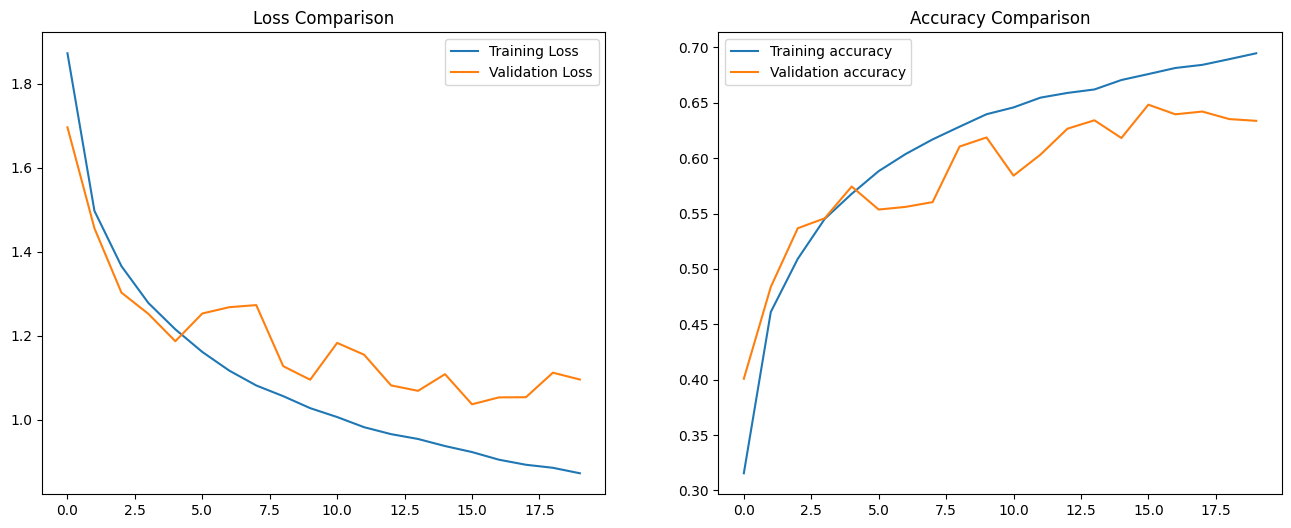

In [18]:
fig, axs = plt.subplots(1, 2, figsize=(16, 6))
axs[0].plot(hist3.history['loss'], label='Training Loss')
axs[0].plot(hist3.history['val_loss'], label='Validation Loss')
axs[0].set_title('Loss Comparison')
axs[1].plot(hist3.history['accuracy'], label='Training accuracy')
axs[1].plot(hist3.history['val_accuracy'], label='Validation accuracy')
axs[1].set_title('Accuracy Comparison')
axs[0].legend()
axs[1].legend()
plt.show()